In [43]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Interpolating $(1 + x^2) / (7 + x^3), [-1, 4]$

In [57]:
f = lambda x: (1 + x**2) / (7 + x**3)
interval_start = -1
interval_end = 4
interval_count = 10
interval_width = (interval_end - interval_start) / interval_count
interp_xs = np.linspace(interval_start, interval_end, interval_count+1)
interp_ys = f(interp_xs)

In [58]:
def approx_deriv(f, *xs):
  if len(xs) == 2:
    return (f(xs[1]) - f(xs[0])) / (xs[1] - xs[0])
  else:
    return (approx_deriv(f, *xs[1:]) - approx_deriv(f, *xs[:-1])) / (xs[-1] - xs[0])

upper_bound = lambda x1,x2,x3: 0.25 * interval_width**2  * approx_deriv(f, x1, x2, x3)

[-1.         -0.94444444 -0.88888889 -0.83333333 -0.77777778 -0.72222222
 -0.66666667 -0.61111111 -0.55555556 -0.5       ] -1.0 0.5
[[ 0.33333333 -0.3030303  -1.        ]
 [ 0.18181818 -0.07792208 -0.5       ]
 [ 0.14285714  0.06516291  0.        ]
 [ 0.1754386   0.14912281  0.5       ]
 [ 0.25        0.12650602  1.        ]
 [ 0.31325301  0.04016064  1.5       ]
 [ 0.33333333 -0.02578269  2.        ]
 [ 0.32044199 -0.05264868  2.5       ]
 [ 0.29411765 -0.05690697  3.        ]
 [ 0.26566416 -0.05245508  3.5       ]]
[0 0 0 0 0 0 0 0 0 1]
[[ 0.33333333 -0.3030303  -1.        ]
 [ 0.33333333 -0.3030303  -1.        ]
 [ 0.33333333 -0.3030303  -1.        ]
 [ 0.33333333 -0.3030303  -1.        ]
 [ 0.33333333 -0.3030303  -1.        ]
 [ 0.33333333 -0.3030303  -1.        ]
 [ 0.33333333 -0.3030303  -1.        ]
 [ 0.33333333 -0.3030303  -1.        ]
 [ 0.33333333 -0.3030303  -1.        ]
 [ 0.18181818 -0.07792208 -0.5       ]]
[-0.5        -0.44444444 -0.38888889 -0.33333333 -0.27777778 -0.

,x,f(x),interp_y,error,upper_bound
0,-1.000000,0.333333,0.333333,0.000000,0.014069
1,-0.944444,0.307260,0.974747,0.667488,0.014069
2,-0.888889,0.284252,-1.195286,1.479538,0.014069
3,-0.833333,0.263879,0.282828,0.018949,0.014069
4,-0.777778,0.245798,0.808081,0.562282,0.014069
5,-0.722222,0.229736,-1.139731,1.369466,0.014069
6,-0.666667,0.215470,0.232323,0.016854,0.014069
7,-0.611111,0.202821,0.489899,0.287078,0.014069
8,-0.555556,0.191643,-1.159211,1.350854,0.014069
9,-0.500000,0.181818,0.333333,0.151515,0.014069


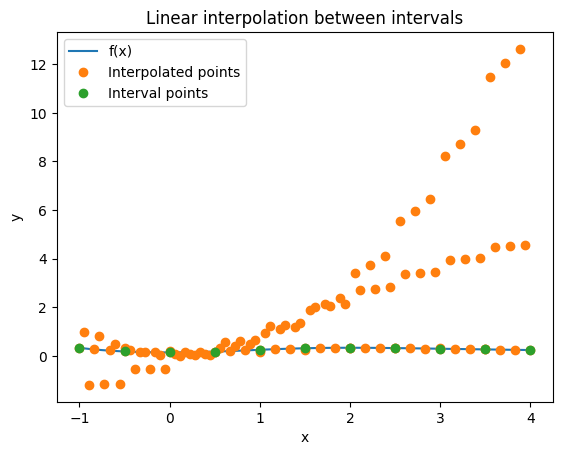

In [89]:
# 1. Linear interpolation
def linear_interpolate(f, xs_to_interpolate):
  interval_count = len(xs_to_interpolate)-1
  interp_coefs = np.zeros((interval_count, 3))
  for i in range(1, len(xs_to_interpolate)):
    x1 = xs_to_interpolate[i-1]
    x2 = xs_to_interpolate[i]
    b = f(x1)
    a = (f(x2) - b) / (x2 - x1) 
    interp_coefs[i-1] = np.array([b, a, x1])
# TODO: for any x common function to find the interpolated y
  interval_start = xs_to_interpolate[0]
  interval_end = xs_to_interpolate[-1]
  segment_width = (interval_end - interval_start) / interval_count
  def get_interpolated_y(x):
    are_xs_in_range = (np.all(interval_start <= x) and np.all(x <= interval_end))
    if not are_xs_in_range:
      raise IndexError("x is out of range")
    print(x, interval_start, segment_width)
    interval_index = np.floor_divide(x - interval_start, segment_width).astype(int)
    interval_index = np.clip(interval_index, 0, interval_count-1)
    print(interp_coefs)
    print(interval_index)
    print(interp_coefs[interval_index])
    b, a, x1 = interp_coefs[interval_index].reshape(3, interval_index.size)
    return b + a * (x - x1)
  return get_interpolated_y

get_interpolated_y = linear_interpolate(f, interp_xs)

def interp_results(f, interp_xs):
  all_interp_xs = []
  all_interp_real_ys = []
  all_interp_ys = []
  errors = []
  upper_bounds = []
  for i in range(1, len(interp_xs)):
    point_count = 10
    xs_in_range = np.linspace(interp_xs[i-1], interp_xs[i], point_count)
    all_interp_xs.extend(xs_in_range)
    function_in_range = f(xs_in_range)
    all_interp_real_ys.extend(function_in_range)
    interp_y = get_interpolated_y(xs_in_range)
    all_interp_ys.extend(interp_y)
    errors.extend(abs(interp_y - function_in_range))
    if i < len(interp_xs) - 1:
      upper_bounds.extend(upper_bound(interp_xs[i-1], interp_xs[i], interp_xs[i+1]) * np.ones(point_count))
    else:
      upper_bounds.extend([0] * point_count)
  print(len(all_interp_xs), len(all_interp_real_ys), len(all_interp_ys), len(errors), len(upper_bounds))
  return pd.DataFrame({
    'x': all_interp_xs,
    'f(x)': all_interp_real_ys,
    'interp_y': all_interp_ys,
    'error': errors,
    'upper_bound': upper_bounds})

def plot_f(f, point_count=100):
  xs = np.linspace(interval_start, interval_end, point_count)
  plt.plot(xs, f(xs), label='f(x)')

plot_f(f)
results = interp_results(f, interp_xs)
plt.plot(results['x'], results['interp_y'], 'o', label='Interpolated points')
plt.plot(interp_xs, interp_ys, 'o', label='Interval points')
plt.title("Linear interpolation between intervals")
plt.ylabel("y")
plt.xlabel("x")
plt.legend()
results[:30]

In [31]:
# Dependencies from previous lab
def I(n, shift=0):
  return np.eye(n, k=shift)

def tri_matrix(n, vals3):
  matrix = I(n) * vals3[1]
  matrix = matrix + I(n, 1) * vals3[0]
  matrix = matrix + I(n, -1) * vals3[2]
  return matrix

def joint_gradient_method(A, b, MAX_ITER_COUNT=1e5, MIN_CONVERGENCE_ERROR=1e-5):
  N = A.shape[0]
  x = np.zeros(N)
  z = p = A @ np.transpose(x) - b
  df = pd.DataFrame(columns=['iter.i', 'sum norm error', *(f'x_(i)_{x_i}' for x_i in range(N))])
  MCESQR = MIN_CONVERGENCE_ERROR * MIN_CONVERGENCE_ERROR
  for i in range(int(MAX_ITER_COUNT)):
    z_prev = np.copy(z)
    x_prev = np.copy(x)
    r = A @ np.transpose(p)
    grad = np.dot(z, p) / np.dot(r, p)
    z = z - grad * r
    x = x - grad * p
    if (np.dot(z, z) < MCESQR):
      break
    p = z + np.dot(z, z) / np.dot(z_prev, z_prev) * p
    error = sum(abs(x - x_prev))
    df.loc[len(df.index)] = [i+1, error, *(x_i for x_i in x)]
  return df, x

In [40]:
# 7. Cubic spline
g_0n = np.random.uniform(-90, 90, 2)
g_0n = np.tan(np.radians(g_0n))
h_fact = 6 * (interval_end - interval_start) / interval_count
A = tri_matrix(interval_count+1, [0.5, 2, 0.5])
A[0, 0] = 1; A[-1, -1] = 1; A[0, 1] = 0; A[-1, -2] = 0
b = np.array(
  [g_0n[0],
  *(6*approx_deriv(f, interp_ys[i], interp_ys[i+1], interp_ys[i+2]) for i in range(len(interp_ys)-2)),
  g_0n[1]])

# TODO: check with linalg
df, g = joint_gradient_method(A, b)

df

,iter.i,sum norm error,x_(i)_0,x_(i)_1,x_(i)_2,x_(i)_3,x_(i)_4,x_(i)_5,x_(i)_6,x_(i)_7,x_(i)_8,x_(i)_9,x_(i)_10
0,1.0,2.466715,-0.054739,0.266732,0.276283,0.272392,0.261761,0.250558,0.245049,0.246590,0.251869,0.257795,0.082948
1,2.0,0.455151,-0.128551,0.357800,0.260452,0.254466,0.242436,0.229838,0.224258,0.226863,0.232846,0.302872,0.194799
2,3.0,0.207454,-0.159442,0.364099,0.235476,0.262372,0.251837,0.240142,0.234786,0.236993,0.223223,0.262289,0.241609
3,4.0,0.049704,-0.160611,0.362924,0.236697,0.269083,0.249315,0.237304,0.231800,0.239255,0.235897,0.247918,0.243381
4,5.0,0.021082,-0.158234,0.362260,0.237490,0.268755,0.247120,0.237972,0.230889,0.235198,0.240804,0.247338,0.239779
5,6.0,0.010596,-0.156794,0.361508,0.237611,0.268375,0.247371,0.239177,0.232230,0.233886,0.240522,0.248669,0.237597
6,7.0,0.005942,-0.156287,0.361087,0.237797,0.268293,0.247657,0.238635,0.232623,0.234375,0.239318,0.249735,0.236829
7,8.0,0.001916,-0.156357,0.361091,0.237886,0.268259,0.247744,0.238251,0.232343,0.234816,0.239055,0.249895,0.236934
8,9.0,0.001290,-0.156533,0.361176,0.237886,0.268209,0.247845,0.238298,0.232146,0.235034,0.239032,0.249771,0.237202
9,10.0,0.000682,-0.156621,0.361228,0.237854,0.268187,0.247831,0.238427,0.232135,0.234993,0.239074,0.249655,0.237335


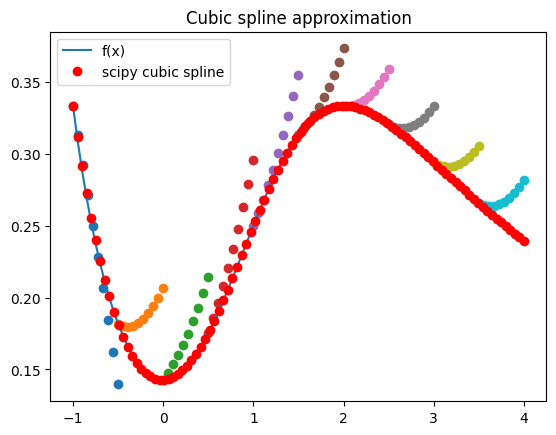

In [41]:
import scipy
import scipy.interpolate

def get_cubic_spline_coefs(g, ys, h):
  coefs = []
  for i in range(1, len(ys)):
    e = (ys[i] - ys[i-1]) / h - g[i] * h/6 + g[i-1] * h/3
    G = g[i-1] / 2
    H = (g[i] - g[i-1]) / (h*6)
    coefs.append((e, G, H))
  return coefs

def plot_cubic_spline(xs, ys, coefs, samples_per_interval):
  for i in range(len(xs) - 1):
    x = np.linspace(xs[i], xs[i+1], samples_per_interval)
    e, G, H = coefs[i]
    y = ys[i] + e * (x - xs[i]) + G * (x - xs[i])**2 + H * (x - xs[i])**3
    plt.plot(x, y, 'o')

coefs = get_cubic_spline_coefs(g, interp_ys, h_fact/6)
plot_cubic_spline(interp_xs, interp_ys, coefs, 10)
plot_f(f, 100)
# plot spline from scipy
xs = np.linspace(interval_start, interval_end, 100)
ys = scipy.interpolate.CubicSpline(interp_xs, interp_ys)(xs)
plt.plot(xs, ys, 'ro', label='scipy cubic spline')
plt.title('Cubic spline approximation')
plt.legend()